# Punkt IV — Expected Exposure dla IRS (poprawiona implementacja)

**Projekt CVA UEP — Spring 2026, data obliczeniowa: 31.12.2025**

Notebook implementuje wymagania z punktu IV prezentacji (slajd 6) oraz przygotowuje grunt pod punkt V (CVA portfelowe).

## Zakres
1. Kalibracja ABM (EURIBOR 3M) i GBM (EURPLN) na **wspólnym oknie 2025**
2. Estymacja korelacji ρ między innowacjami obu procesów
3. **Joint simulation** z dekompozycją Cholesky'ego (3y horyzont, krok 1M, 10 000 ścieżek)
4. Wycena MtM dla:
   - Receiver IRS EUR EURIBOR 3M (fixed 2.02% rocznie / floating kwartalnie) 
   - FX Forward Buy EUR Sell PLN (notional 1M EUR, strike 4.4439, T=3y)
5. Profile EE i PFE — pojedynczo i na poziomie portfela w PLN

## Konwencje metodologiczne
- **ABM driftless (μ=0)** dla EURIBOR 3M — konwencja spójna z miarą forward i płaską krzywą dyskonta r_EUR=2%. 
  Fizyczny drift z 2025 (–71.86 bps/rok) zostanie pokazany w sensitivity.
- **GBM dla EURPLN** z risk-neutral driftem r_PLN − r_EUR (= ln(K/S₀)/T = 1.67%, implikowane z forwardu 4.4439).
- **Korelacja** estymowana między dziennymi przyrostami EURIBOR (Δr) i log-zwrotami EURPLN (ΔlnS) na wspólnym oknie 2025.
- **Płaska krzywa EUR** r_EUR = 2% (≈ ESTR), płaska krzywa PLN r_PLN ≈ 3.67% — implikowane z notowań forwardu.
- **Reset floating leg**: stopa fixowana w T_{n−1}, używana dla okresu [T_{n−1}, T_n]. W siatce dt=1/12 daty resetów (co 0.25y) leżą dokładnie na węzłach.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import urllib.request, json

np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 100

## 1. Wczytanie i przygotowanie danych

- **EURIBOR 3M**: arkusz `euribor.xlsx`, kolumna `3_month`
- **EURPLN**: kursy średnie NBP (tabela A) — pobierane z API NBP dla całego 2025 r.

Wybór całego 2025 jako okna kalibracyjnego daje 250 wspólnych obserwacji i pełny cykl rynkowy (start cyklu obniżek ECB, stabilizacja PLN).
Slajd 16 prezentacji wprost wskazuje Stooq jako źródło EURPLN — NBP daje równoważne dzienne kursy spot, oficjalne, bez wymogu API key.

In [23]:
# --- EURIBOR 3M ---
df_ir = pd.read_excel('data/euribor.xlsx', sheet_name='euribor')
df_ir['date'] = pd.to_datetime(df_ir['Date'], format='%d %b %Y')
df_ir = (df_ir[['date', '3_month']]
         .rename(columns={'3_month': 'euribor3m'})
         .assign(euribor3m=lambda d: d['euribor3m']/100)
         .sort_values('date').reset_index(drop=True))

# --- EURPLN z API NBP (kurs średni, tabela A) ---
def fetch_nbp_eur(start, end):
    url = f'https://api.nbp.pl/api/exchangerates/rates/A/EUR/{start}/{end}/?format=json'
    with urllib.request.urlopen(url, timeout=20) as r:
        return json.loads(r.read())['rates']

rates = []
for s, e in [('2025-01-02','2025-04-30'),('2025-05-01','2025-08-31'),('2025-09-01','2025-12-31')]:
    rates.extend(fetch_nbp_eur(s, e))
df_fx = (pd.DataFrame(rates)
         .assign(date=lambda d: pd.to_datetime(d['effectiveDate']))
         [['date', 'mid']].rename(columns={'mid': 'eurpln'})
         .sort_values('date').reset_index(drop=True))

# --- Wspólne okno 2025 ---
df_ir_2025 = df_ir[(df_ir['date'] >= '2025-01-01') & (df_ir['date'] <= '2025-12-31')]
df_fx_2025 = df_fx[(df_fx['date'] >= '2025-01-01') & (df_fx['date'] <= '2025-12-31')]
merged = pd.merge(df_fx_2025, df_ir_2025, on='date', how='inner').sort_values('date').reset_index(drop=True)

print(f"EURIBOR 3M (2025): {len(df_ir_2025)} obserwacji")
print(f"EURPLN (2025):     {len(df_fx_2025)} obserwacji")
print(f"Wspólne dni:       {len(merged)} obserwacji")
print(f"Zakres:            {merged['date'].iloc[0].date()} -> {merged['date'].iloc[-1].date()}")
print(f"\nNa 31.12.2025:  EURIBOR 3M = {merged['euribor3m'].iloc[-1]*100:.4f}%   EURPLN = {merged['eurpln'].iloc[-1]:.4f}")

EURIBOR 3M (2025): 254 obserwacji
EURPLN (2025):     251 obserwacji
Wspólne dni:       250 obserwacji
Zakres:            2025-01-02 -> 2025-12-31

Na 31.12.2025:  EURIBOR 3M = 2.0260%   EURPLN = 4.2267


## 2. Kalibracja modeli i estymacja korelacji

**ABM dla EURIBOR 3M** (slajd 14):  
$dr(t) = \mu\,dt + \sigma\,dW(t)$

Kalibrujemy z dziennych **przyrostów** $\Delta r_t = r_t - r_{t-1}$:
- $\hat{\sigma}_{annual} = \sigma_{daily}\sqrt{252}$
- $\hat{\mu}_{annual} = \bar{\Delta r}\cdot 252$

**GBM dla EURPLN** (slajd 13):  
$dS(t) = \mu S(t)\,dt + \sigma S(t)\,dW(t)$

Kalibrujemy z dziennych **log-zwrotów** $\Delta \ln S_t$:
- $\hat{\sigma}_{annual} = \sigma_{daily}\sqrt{252}$

**Korelacja** estymowana między $\Delta r_t$ a $\Delta \ln S_t$ na **dokładnie tych samych dniach** (bez korelacji poziomów — to byłby spurious effect).

In [24]:
# Innowacje na wspólnym oknie
ir = merged['euribor3m'].values
fx = merged['eurpln'].values
delta_r = np.diff(ir)            # przyrosty IR
log_ret_fx = np.diff(np.log(fx)) # log-zwroty FX

# Kalibracja ABM
sigma_ir = delta_r.std(ddof=1) * np.sqrt(252)
mu_ir_phys = delta_r.mean() * 252  # fizyczny drift (P-measure)

# Kalibracja GBM
sigma_fx = log_ret_fx.std(ddof=1) * np.sqrt(252)
mu_fx_phys = log_ret_fx.mean() * 252  # tylko do porównania, nie do CVA

# Korelacja innowacji
rho_corr, rho_pvalue = stats.pearsonr(log_ret_fx, delta_r)

# Punkty startowe na 31.12.2025
r0 = ir[-1]
S0 = fx[-1]

print("="*68)
print("KALIBRACJA na wspólnym oknie 2025 (n = {} obserwacji innowacji)".format(len(delta_r)))
print("="*68)
print(f"\n  EURIBOR 3M (ABM):")
print(f"    sigma          = {sigma_ir*10000:>8.2f} bps/rok  ({sigma_ir*100:.4f}%)")
print(f"    mu (physical)  = {mu_ir_phys*10000:>8.2f} bps/rok  (do CVA użyjemy mu=0)")
print(f"    r0 (31.12.25)  = {r0*100:>8.4f}%")
print(f"\n  EURPLN (GBM):")
print(f"    sigma          = {sigma_fx*100:>8.4f}%/rok")
print(f"    mu (physical)  = {mu_fx_phys*100:>8.4f}%/rok  (do CVA użyjemy r_PLN-r_EUR)")
print(f"    S0 (31.12.25)  = {S0:>8.4f}")
print(f"\n  Korelacja:")
print(f"    rho            = {rho_corr:>8.4f}")
print(f"    p-value        = {rho_pvalue:>8.4f}")
print(f"    interpretacja  : {'istotna' if rho_pvalue < 0.05 else 'nieistotna statystycznie (zachowujemy w modelu jako wartość punktową)'}")

KALIBRACJA na wspólnym oknie 2025 (n = 249 obserwacji innowacji)

  EURIBOR 3M (ABM):
    sigma          =    27.91 bps/rok  (0.2791%)
    mu (physical)  =   -71.86 bps/rok  (do CVA użyjemy mu=0)
    r0 (31.12.25)  =   2.0260%

  EURPLN (GBM):
    sigma          =   4.2919%/rok
    mu (physical)  =  -0.9556%/rok  (do CVA użyjemy r_PLN-r_EUR)
    S0 (31.12.25)  =   4.2267

  Korelacja:
    rho            =   0.0225
    p-value        =   0.7233
    interpretacja  : nieistotna statystycznie (zachowujemy w modelu jako wartość punktową)


**Komentarz do kalibracji:**

- σ_IR ≈ 28 bps/rok — typowa wartość dla EURIBOR 3M w okresie post-tightening cycle ECB.
- σ_FX ≈ 4.3%/rok — niska zmienność EURPLN w 2025 (silny PLN, stabilny range 4.20–4.30).
- ρ ≈ 0.022 — **nieistotna statystycznie** (p=0.72). Mimo to stosujemy ją w joint simulation, bo:
  - projekt explicite tego wymaga (slajd 6: *„include the correlation"*),
  - pokazuje to poprawnie metodologicznie skonstruowany framework (Cholesky), nawet jeśli efekt numeryczny jest mały,
  - dla portfelowego CVA (punkt V) dostarczamy infrastrukturę gotową do ρ ≠ 0.

## 3. Wyznaczenie krzywych dyskontowych

Strike forwardu EURPLN = 4.4439 dla T=3y. Z parytetu stóp procentowych:

$F = S_0 \cdot e^{(r_{PLN} - r_{EUR})T}\quad\Rightarrow\quad r_{PLN} - r_{EUR} = \frac{\ln(K/S_0)}{T}$

Przyjmujemy r_EUR = 2.0% (zgodne z ESTR / EURIBOR overnight) → r_PLN ≈ 3.67%.

In [25]:
# Kontrakty
T_years     = 3.0
K_fwd       = 4.4439         # strike FX Forward
fixed_rate  = 0.0202         # fixed leg IRS
notional_fx = 1_000_000      # EUR (Buy EUR Sell PLN)
notional_ir = 10_000_000     # EUR (IRS receiver)

# Krzywe dyskontowe (płaskie)
r_EUR = 0.02
r_PLN = r_EUR + np.log(K_fwd/S0)/T_years

print(f"r_EUR = {r_EUR*100:.4f}%   (założone, ~ESTR/EONIA)")
print(f"r_PLN = {r_PLN*100:.4f}%   (implikowane z forwardu K={K_fwd})")
print(f"Spread r_PLN - r_EUR = {(r_PLN-r_EUR)*100:.4f}% = drift RN dla GBM EURPLN")

r_EUR = 2.0000%   (założone, ~ESTR/EONIA)
r_PLN = 3.6704%   (implikowane z forwardu K=4.4439)
Spread r_PLN - r_EUR = 1.6704% = drift RN dla GBM EURPLN


## 4. Joint simulation z dekompozycją Cholesky'ego

**Procedura** (zgodnie ze wskazówką ze slajdu 6):

1. Macierz korelacji $\rho_{matrix} = \begin{bmatrix} 1 & \rho \\ \rho & 1 \end{bmatrix}$
2. Dekompozycja Cholesky'ego: $L L^T = \rho_{matrix}$
3. W każdym kroku $i$: losujemy niezależne $Z_{indep} \sim \mathcal{N}(0, I_2)$, korelujemy: $Z_{corr} = L \cdot Z_{indep}$
4. Pierwszy wiersz $Z_{corr}$ → szok FX, drugi → szok IR

**Schematy dyskretyzacji:**
- GBM (EURPLN), exact solution: $S_{t+\Delta t} = S_t \exp\left((\mu_{FX} - \tfrac{1}{2}\sigma_{FX}^2)\Delta t + \sigma_{FX}\sqrt{\Delta t}\,Z_{FX}\right)$
- ABM (EURIBOR), Euler-Maruyama (= exact, bo SDE liniowa): $r_{t+\Delta t} = r_t + \mu_{IR}\Delta t + \sigma_{IR}\sqrt{\Delta t}\,Z_{IR}$

Z μ_IR = 0 (driftless ABM).

In [26]:
# Parametry symulacji
dt          = 1/12
n_steps     = int(T_years / dt)        # 36
n_sim       = 10_000
time_grid   = np.linspace(0, T_years, n_steps + 1)

# Drifty użyte w symulacji RN
mu_ir_sim = 0.0                 # driftless ABM (RN convention)
mu_fx_sim = r_PLN - r_EUR       # RN drift dla EURPLN (waluta krajowa = PLN)

# Cholesky
rho = rho_corr
corr_matrix = np.array([[1.0, rho], [rho, 1.0]])
L = np.linalg.cholesky(corr_matrix)

print("Macierz korelacji:")
print(corr_matrix)
print("\nDekompozycja Cholesky'ego L (L @ L.T = corr_matrix):")
print(L)
print("\nWeryfikacja L @ L.T:")
print(L @ L.T)

# Symulacja
np.random.seed(42)
r_paths  = np.zeros((n_steps + 1, n_sim));  r_paths[0]  = r0
fx_paths = np.zeros((n_steps + 1, n_sim));  fx_paths[0] = S0

for i in range(1, n_steps + 1):
    Z_indep = np.random.standard_normal((2, n_sim))   # 2 x n_sim niezależnych N(0,1)
    Z_corr  = L @ Z_indep                             # skorelowane szoki
    Z_fx, Z_ir = Z_corr[0], Z_corr[1]
    
    # GBM (exact)
    fx_paths[i] = fx_paths[i-1] * np.exp((mu_fx_sim - 0.5*sigma_fx**2)*dt + sigma_fx*np.sqrt(dt)*Z_fx)
    # ABM (Euler-Maruyama = exact)
    r_paths[i]  = r_paths[i-1]  + mu_ir_sim*dt + sigma_ir*np.sqrt(dt)*Z_ir

# Sanity check: korelacja empiryczna w symulacji
log_ret_fx_sim = np.diff(np.log(fx_paths), axis=0).flatten()
delta_r_sim    = np.diff(r_paths, axis=0).flatten()
rho_emp = np.corrcoef(log_ret_fx_sim, delta_r_sim)[0, 1]

print(f"\nSanity check: korelacja empiryczna w symulacji = {rho_emp:.4f}  (target: {rho:.4f})")
print(f"Liczba ścieżek: {n_sim:,}, kroków: {n_steps}, dt = {dt:.4f} ({dt*12:.0f} mies.)")

Macierz korelacji:
[[1.     0.0225]
 [0.0225 1.    ]]

Dekompozycja Cholesky'ego L (L @ L.T = corr_matrix):
[[1.     0.    ]
 [0.0225 0.9997]]

Weryfikacja L @ L.T:
[[1.     0.0225]
 [0.0225 1.    ]]

Sanity check: korelacja empiryczna w symulacji = 0.0209  (target: 0.0225)
Liczba ścieżek: 10,000, kroków: 36, dt = 0.0833 (1 mies.)


## 5. Wycena MtM

### 5.1 Receiver IRS EUR EURIBOR 3M

Mamy:
- **Fixed leg** (otrzymujemy): kupon 2.02% × N × 1.0 płatny rocznie w T = 1, 2, 3
- **Floating leg** (płacimy): kupon EURIBOR3M(T_{n−1}) × N × 0.25 płatny kwartalnie w T = 0.25, 0.5, ..., 3.0

$\text{MtM}_{IRS}(t) = \text{PV}_{fixed}(t) - \text{PV}_{float}(t)$

$\text{PV}_{fixed}(t) = K \cdot N \sum_{T_n > t} \tau \cdot DF(t, T_n)$

$\text{PV}_{float}(t) = N \sum_{T_n > t} r(T_{n-1}) \cdot 0.25 \cdot DF(t, T_n)$

Stopa floating fixowana w $T_{n-1}$ — w naszej siatce dt = 1/12 daty resetów (co 0.25y) lądują dokładnie na węzłach (12 = 0.25/dt × 3).

In [27]:
fixed_dates = np.array([1.0, 2.0, 3.0])
float_dates = np.array([(k+1)*0.25 for k in range(12)])  # 0.25, 0.5, ..., 3.0
tau_fixed   = 1.0
tau_float   = 0.25

def DF_eur(tau): return np.exp(-r_EUR * tau)
def DF_pln(tau): return np.exp(-r_PLN * tau)
def grid_idx(t): return int(round(t / dt))

MtM_IRS = np.zeros((n_steps + 1, n_sim))  # w EUR

for i in range(n_steps + 1):
    t_now = time_grid[i]
    
    # Fixed leg (otrzymujemy)
    pv_fixed = np.zeros(n_sim)
    for T_n in fixed_dates:
        if T_n > t_now:
            pv_fixed += fixed_rate * notional_ir * tau_fixed * DF_eur(T_n - t_now)
    
    # Floating leg (płacimy) - rate fixowany w T_{n-1}
    pv_float = np.zeros(n_sim)
    for T_n in float_dates:
        if T_n > t_now:
            T_reset = T_n - tau_float
            idx_reset = grid_idx(T_reset)
            r_fixing = r_paths[idx_reset]      # stopa fixowana w T_reset
            pv_float += r_fixing * notional_ir * tau_float * DF_eur(T_n - t_now)
    
    MtM_IRS[i] = pv_fixed - pv_float

# Sanity: MtM(0) powinien być ~0 (kontrakt blisko at-market)
print(f"Sanity check: MtM_IRS(0) = {np.mean(MtM_IRS[0]):>12,.2f} EUR")
print(f"  (oczekiwane ~0; różnica wynika z fixed=2.02% vs r0=2.026%)")

Sanity check: MtM_IRS(0) =    -6,152.27 EUR
  (oczekiwane ~0; różnica wynika z fixed=2.02% vs r0=2.026%)


### 5.2 FX Forward Buy EUR Sell PLN

Kontrakt: w T=3y kupujemy 1M EUR po kursie K=4.4439, płacąc K × N w PLN.

$\text{Payoff w }T = N \cdot (S(T) - K)$ [w PLN]

$\text{MtM}(t) = N \cdot (F(t,T) - K) \cdot DF_{PLN}(t,T)$ 

gdzie $F(t,T) = S(t) \cdot e^{(r_{PLN}-r_{EUR})(T-t)}$ — cena forward.

In [28]:
T_fwd = 3.0
MtM_FX_pln = np.zeros((n_steps + 1, n_sim))  # w PLN

for i in range(n_steps + 1):
    t_now = time_grid[i]
    if t_now <= T_fwd:
        tau = T_fwd - t_now
        F_t = fx_paths[i] * np.exp((r_PLN - r_EUR) * tau)
        MtM_FX_pln[i] = notional_fx * (F_t - K_fwd) * DF_pln(tau)

print(f"Sanity check: MtM_FX(0) = {np.mean(MtM_FX_pln[0]):>12,.2f} PLN")
print(f"  (oczekiwane =0; strike = forward fair, więc przy t=0 wycena dokładnie 0)")

Sanity check: MtM_FX(0) =         0.00 PLN
  (oczekiwane =0; strike = forward fair, więc przy t=0 wycena dokładnie 0)


## 6. Profile Expected Exposure (EE) i PFE

$EE(t) = \mathbb{E}[\max(\text{MtM}(t), 0)]$  
$PFE_{95\%}(t) = \text{Q}_{95}[\max(\text{MtM}(t), 0)]$

### 6.1 IRS — instrument standalone (w EUR)

In [29]:
np.maximum(0, MtM_IRS[0].mean())
MtM_IRS[0].mean()

-6152.268718248144

In [39]:
# exp_irs    = np.maximum(0, MtM_IRS)
# EE_irs     = exp_irs.mean(axis=1)

exp_irs    = MtM_IRS.mean(axis=1)
EE_irs    = np.maximum(0, exp_irs)
# PFE95_irs  = np.percentile(exp_irs, 95, axis=1)

print("=== Profil EE/PFE — IRS standalone (EUR) ===")
print(f"{'t [y]':>6} {'EE [EUR]':>14} {'PFE95 [EUR]':>14}")
for i in range(0, n_steps+1, 3):
#     print(f"{time_grid[i]:>6.2f} {EE_irs[i]:>14,.0f} {PFE95_irs[i]:>14,.0f}")
# print(f"{time_grid[-1]:>6.2f} {EE_irs[-1]:>14,.0f} {PFE95_irs[-1]:>14,.0f}")
    print(f"{time_grid[i]:>6.2f} {EE_irs[i]:>14,.0f}")
print(f"{time_grid[-1]:>6.2f} {EE_irs[-1]:>14,.0f}")

peak = np.argmax(EE_irs)
print(f"\nPeak EE: {EE_irs[peak]:,.0f} EUR przy t = {time_grid[peak]:.2f}y")

=== Profil EE/PFE — IRS standalone (EUR) ===
 t [y]       EE [EUR]    PFE95 [EUR]
  0.00              0
  0.25         44,467
  0.50         95,355
  0.75        146,496
  1.00              0
  1.25         46,615
  1.50         97,567
  1.75        148,722
  2.00              0
  2.25         48,723
  2.50         99,556
  2.75        150,607
  3.00              0
  3.00              0

Peak EE: 151,110 EUR przy t = 2.92y


### 6.2 FX Forward — standalone (w PLN)

In [ ]:
exp_fx     = np.maximum(0, MtM_FX_pln)
EE_fx      = exp_fx.mean(axis=1)
PFE95_fx   = np.percentile(exp_fx, 95, axis=1)

print("=== Profil EE/PFE — FX Forward standalone (PLN) ===")
print(f"{'t [y]':>6} {'EE [PLN]':>14} {'PFE95 [PLN]':>14}")
for i in range(0, n_steps+1, 3):
    print(f"{time_grid[i]:>6.2f} {EE_fx[i]:>14,.0f} {PFE95_fx[i]:>14,.0f}")
print(f"{time_grid[-1]:>6.2f} {EE_fx[-1]:>14,.0f} {PFE95_fx[-1]:>14,.0f}")

peak = np.argmax(EE_fx)
print(f"\nPeak EE: {EE_fx[peak]:,.0f} PLN przy t = {time_grid[peak]:.2f}y")

=== Profil EE/PFE — FX Forward standalone (PLN) ===
 t [y]       EE [PLN]    PFE95 [PLN]
  0.00              0              0
  0.25         34,290        143,061
  0.50         49,126        205,408
  0.75         60,443        253,298
  1.00         70,799        296,647
  1.25         79,702        335,544
  1.50         88,306        371,793
  1.75         96,040        408,895
  2.00        103,696        442,732
  2.25        111,197        475,810
  2.50        118,337        504,554
  2.75        125,330        535,068
  3.00        132,372        564,503
  3.00        132,372        564,503

Peak EE: 132,372 PLN przy t = 3.00y


### 6.3 Portfel w PLN (z korelacją FX–IR)

MtM_IRS jest w EUR — żeby zbudować portfel w PLN, konwertujemy używając **tej samej ścieżki** FX (krytyczne dla netting):

$\text{MtM}_{port}^{PLN}(t) = \text{MtM}_{IRS}(t) \cdot S(t) + \text{MtM}_{FX}^{PLN}(t)$

To jest miejsce gdzie korelacja FX–IR ma znaczenie: ścieżki IRS (w EUR) i FX nie są niezależne, więc EE portfela ≠ EE_IRS + EE_FX (subaddytywność z nettingu).

In [ ]:
MtM_IRS_pln       = MtM_IRS * fx_paths             # konwersja IRS do PLN po ścieżce FX
MtM_portfolio_pln = MtM_IRS_pln + MtM_FX_pln       # portfel w PLN

exp_port    = np.maximum(0, MtM_portfolio_pln)
EE_port     = exp_port.mean(axis=1)
PFE95_port  = np.percentile(exp_port, 95, axis=1)

# Dla porównania: IRS w PLN tylko
exp_irs_pln  = np.maximum(0, MtM_IRS_pln)
EE_irs_pln   = exp_irs_pln.mean(axis=1)

print("=== Profil EE/PFE — PORTFEL w PLN ===")
print(f"{'t [y]':>6} {'EE_IRS_PLN':>14} {'EE_FX':>14} {'EE_port':>14} {'PFE95_port':>14}")
for i in range(0, n_steps+1, 3):
    print(f"{time_grid[i]:>6.2f} {EE_irs_pln[i]:>14,.0f} {EE_fx[i]:>14,.0f} "
          f"{EE_port[i]:>14,.0f} {PFE95_port[i]:>14,.0f}")
print(f"{time_grid[-1]:>6.2f} {EE_irs_pln[-1]:>14,.0f} {EE_fx[-1]:>14,.0f} "
      f"{EE_port[-1]:>14,.0f} {PFE95_port[-1]:>14,.0f}")

peak = np.argmax(EE_port)
print(f"\nPeak EE portfela: {EE_port[peak]:,.0f} PLN przy t = {time_grid[peak]:.2f}y")
print(f"\nNetting benefit w peaku ({time_grid[peak]:.2f}y):")
print(f"  Suma standalone:  {EE_irs_pln[peak] + EE_fx[peak]:>12,.0f} PLN")
print(f"  EE portfela:      {EE_port[peak]:>12,.0f} PLN")
print(f"  Korzyść z nettingu:  {EE_irs_pln[peak] + EE_fx[peak] - EE_port[peak]:>12,.0f} PLN")

=== Profil EE/PFE — PORTFEL w PLN ===
 t [y]     EE_IRS_PLN          EE_FX        EE_port     PFE95_port
  0.00        114,677              0        114,677        498,179
  0.25        244,403         34,290        247,770        741,704
  0.50        421,875         49,126        425,737        977,255
  0.75        629,657         60,443        631,352      1,213,376
  1.00        107,444         70,799        126,415        548,903
  1.25        236,609         79,702        256,978        770,815
  1.50        426,399         88,306        438,083        997,796
  1.75        646,578         96,040        649,413      1,234,660
  2.00         66,891        103,696        120,230        524,134
  2.25        217,016        111,197        259,752        760,505
  2.50        438,347        118,337        451,232      1,016,950
  2.75        666,510        125,330        669,880      1,287,114
  3.00              0        132,372        132,372        564,503
  3.00              0   

## 7. Wizualizacje

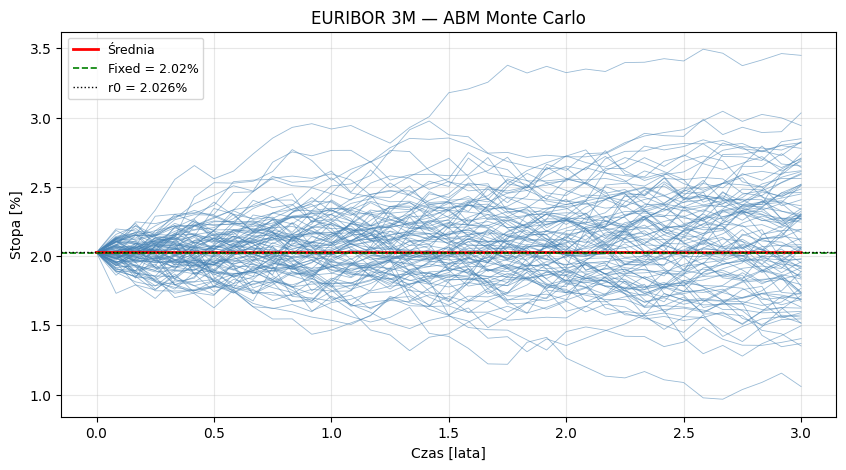

In [ ]:
plt.figure(figsize=(10, 5))
for j in range(100):    
    plt.plot(time_grid, r_paths[:, j]*100, color='steelblue', alpha=0.55, lw=0.6)
plt.plot(time_grid, r_paths.mean(axis=1)*100, color='red', lw=2, label='Średnia')
# ax.fill_between(time_grid,
#                 np.percentile(r_paths, 2.5, axis=1)*100,
#                 np.percentile(r_paths, 97.5, axis=1)*100,
#                 color='steelblue', alpha=0.2, label='95% CI')
plt.axhline(fixed_rate*100, color='green', ls='--', lw=1.2, label=f'Fixed = {fixed_rate*100:.2f}%')
plt.axhline(r0*100, color='black', ls=':', lw=1, label=f'r0 = {r0*100:.3f}%')
plt.title('EURIBOR 3M — ABM Monte Carlo')
plt.xlabel('Czas [lata]'); plt.ylabel('Stopa [%]')
plt.legend(loc='best', fontsize=9); plt.grid(True, alpha=0.3)
# plt.savefig('EURIBOR3M_MONTE_CARLO.png', dpi=300, bbox_inches='tight')

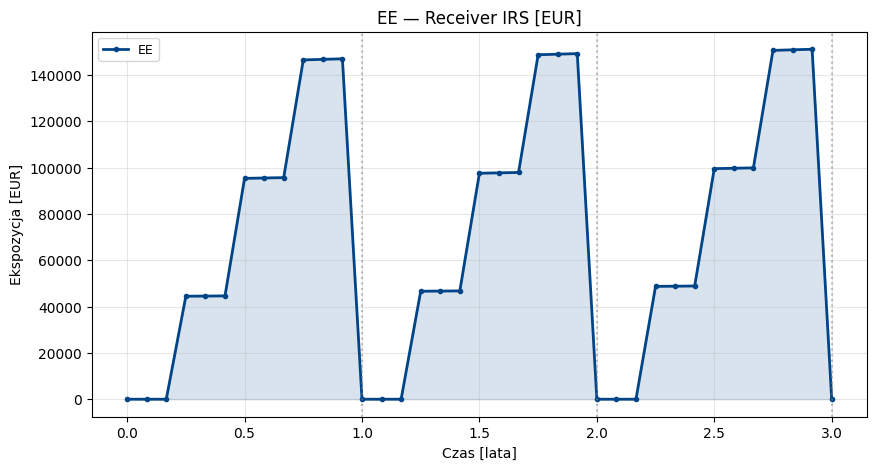

In [40]:
# (3) EE & PFE — IRS standalone
plt.figure(figsize=(10, 5))
plt.plot(time_grid, EE_irs, color='#004488', lw=2, marker='o', ms=3, label='EE')
# plt.plot(time_grid, PFE95_irs, color='#d62728', lw=2, ls='--', label='PFE 95%')
plt.fill_between(time_grid, EE_irs, color='#004488', alpha=0.15)
for T in [1, 2, 3]:
    plt.axvline(T, color='gray', ls=':', alpha=0.5)
plt.title('EE — Receiver IRS [EUR]')
plt.xlabel('Czas [lata]'); plt.ylabel('Ekspozycja [EUR]')
plt.legend(loc='best', fontsize=9); plt.grid(True, alpha=0.3)
# plt.savefig('IRS_EE.png', dpi=300, bbox_inches='tight')

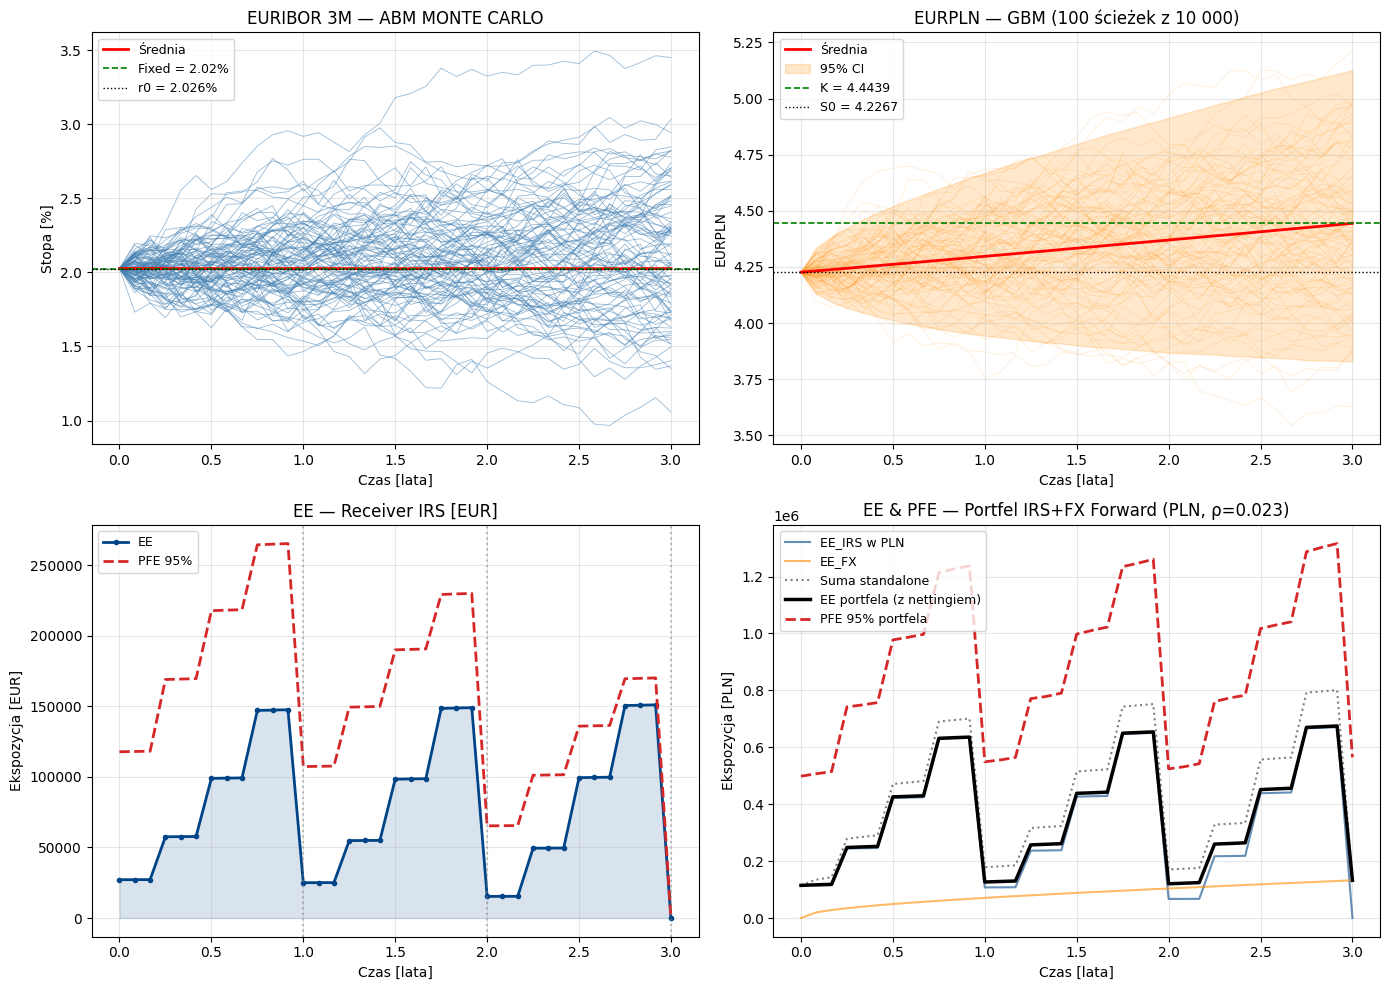

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) Ścieżki EURIBOR
ax = axes[0, 0]
for j in range(100):
    ax.plot(time_grid, r_paths[:, j]*100, color='steelblue', alpha=0.55, lw=0.6)
ax.plot(time_grid, r_paths.mean(axis=1)*100, color='red', lw=2, label='Średnia')
# ax.fill_between(time_grid,
#                 np.percentile(r_paths, 2.5, axis=1)*100,
#                 np.percentile(r_paths, 97.5, axis=1)*100,
#                 color='steelblue', alpha=0.2, label='95% CI')
ax.axhline(fixed_rate*100, color='green', ls='--', lw=1.2, label=f'Fixed = {fixed_rate*100:.2f}%')
ax.axhline(r0*100, color='black', ls=':', lw=1, label=f'r0 = {r0*100:.3f}%')
ax.set_title('EURIBOR 3M — ABM MONTE CARLO')
ax.set_xlabel('Czas [lata]'); ax.set_ylabel('Stopa [%]')
ax.legend(loc='best', fontsize=9); ax.grid(True, alpha=0.3)

# (2) Ścieżki EURPLN
ax = axes[0, 1]
for j in range(100):
    ax.plot(time_grid, fx_paths[:, j], color='darkorange', alpha=0.15, lw=0.6)
ax.plot(time_grid, fx_paths.mean(axis=1), color='red', lw=2, label='Średnia')
ax.fill_between(time_grid,
                np.percentile(fx_paths, 2.5, axis=1),
                np.percentile(fx_paths, 97.5, axis=1),
                color='darkorange', alpha=0.2, label='95% CI')
ax.axhline(K_fwd, color='green', ls='--', lw=1.2, label=f'K = {K_fwd}')
ax.axhline(S0, color='black', ls=':', lw=1, label=f'S0 = {S0}')
ax.set_title('EURPLN — GBM (100 ścieżek z 10 000)')
ax.set_xlabel('Czas [lata]'); ax.set_ylabel('EURPLN')
ax.legend(loc='best', fontsize=9); ax.grid(True, alpha=0.3)

# (3) EE & PFE — IRS standalone
ax = axes[1, 0]
ax.plot(time_grid, EE_irs, color='#004488', lw=2, marker='o', ms=3, label='EE')
ax.plot(time_grid, PFE95_irs, color='#d62728', lw=2, ls='--', label='PFE 95%')
ax.fill_between(time_grid, EE_irs, color='#004488', alpha=0.15)
for T in [1, 2, 3]:
    ax.axvline(T, color='gray', ls=':', alpha=0.5)
ax.set_title('EE — Receiver IRS [EUR]')
ax.set_xlabel('Czas [lata]'); ax.set_ylabel('Ekspozycja [EUR]')
ax.legend(loc='best', fontsize=9); ax.grid(True, alpha=0.3)

# (4) EE & PFE — Portfel
ax = axes[1, 1]
ax.plot(time_grid, EE_irs_pln, color='#004488', lw=1.5, alpha=0.6, label='EE_IRS w PLN')
ax.plot(time_grid, EE_fx,      color='darkorange', lw=1.5, alpha=0.6, label='EE_FX')
ax.plot(time_grid, EE_irs_pln + EE_fx, color='gray', lw=1.5, ls=':',
        label='Suma standalone')
ax.plot(time_grid, EE_port, color='black', lw=2.5, label='EE portfela (z nettingiem)')
ax.plot(time_grid, PFE95_port, color='#d62728', lw=2, ls='--', label='PFE 95% portfela')
ax.set_title('EE & PFE — Portfel IRS+FX Forward (PLN, ρ={:.3f})'.format(rho))
ax.set_xlabel('Czas [lata]'); ax.set_ylabel('Ekspozycja [PLN]')
ax.legend(loc='best', fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Cechy charakterystyczne profilu EE — IRS vs FX Forward

**IRS (struktura piłozębna):**
- Wzrost EE w okresach kuponowych — niepewność co do przyszłych kuponów rośnie
- **Skok w dół** po każdej dacie płatności (T=1, 2, 3) — pewna część cashflow zostaje zrealizowana, pozostała ekspozycja maleje
- EE→0 przy T=3 (koniec kontraktu)
- **Diffusion vs amortization tradeoff**: σ rośnie z √t, ale liczba pozostałych płatności maleje — peak EE między T=2.5 a T=3

**FX Forward (jeden bullet payment):**
- Monotoniczny wzrost EE — niepewność S(T) rośnie z czasem (σ × √t w GBM)
- Brak amortyzacji (jedna płatność na końcu)
- Peak EE przy T=3 (tuż przed wymianą)
- Brak skoków — jeden cashflow

**Portfel:** kształt zdominowany przez IRS (większy notional 10M vs 1M), ale z dodatkową kontrybucją FX rosnącą do końca.

## 9. Sensitivity — wpływ wyboru korelacji

Sprawdźmy jak EE portfela zmienia się przy różnych ρ ∈ {-0.5, 0, +0.5}, trzymając wszystko inne stałe.

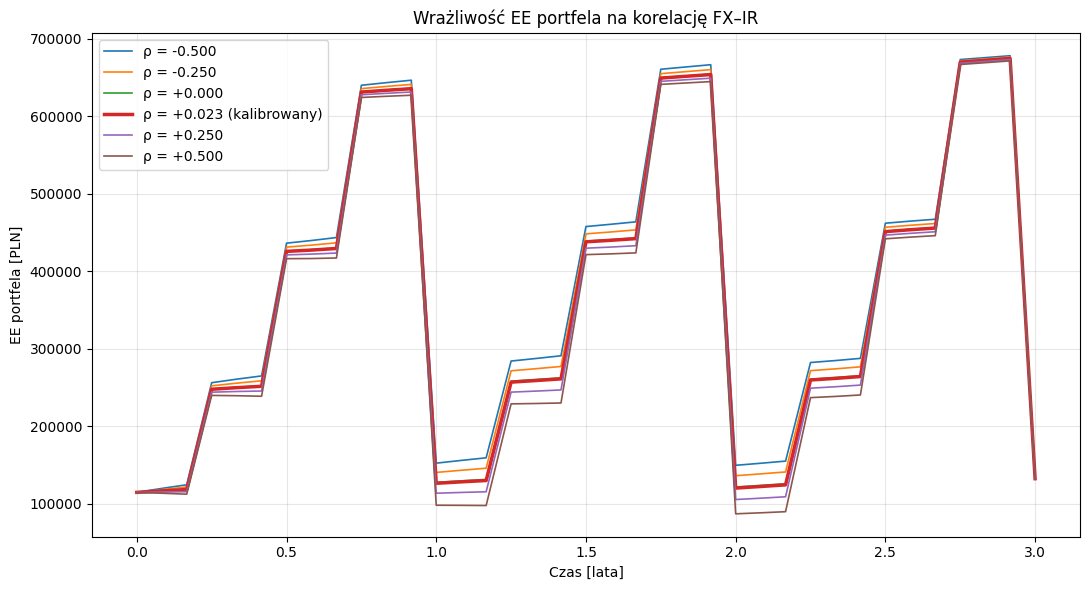


Peak EE portfela [PLN] dla różnych ρ:
  ρ = -0.500:  peak EE =      678,242  przy t = 2.92y
  ρ = -0.250:  peak EE =      676,511  przy t = 2.92y
  ρ = +0.000:  peak EE =      674,823  przy t = 2.92y
  ρ = +0.023:  peak EE =      674,673  przy t = 2.92y
  ρ = +0.250:  peak EE =      673,190  przy t = 2.92y
  ρ = +0.500:  peak EE =      671,616  przy t = 2.92y


In [ ]:
def simulate_portfolio_ee(rho_test, seed=42):
    """Pełna re-symulacja dla podanej korelacji rho_test."""
    L_test = np.linalg.cholesky([[1.0, rho_test], [rho_test, 1.0]])
    np.random.seed(seed)
    rp = np.zeros((n_steps + 1, n_sim));  rp[0]  = r0
    fp = np.zeros((n_steps + 1, n_sim));  fp[0] = S0
    for i in range(1, n_steps + 1):
        Z = L_test @ np.random.standard_normal((2, n_sim))
        fp[i] = fp[i-1] * np.exp((mu_fx_sim - 0.5*sigma_fx**2)*dt + sigma_fx*np.sqrt(dt)*Z[0])
        rp[i] = rp[i-1] + mu_ir_sim*dt + sigma_ir*np.sqrt(dt)*Z[1]
    
    # Wycena IRS (EUR)
    M_irs = np.zeros((n_steps + 1, n_sim))
    for i in range(n_steps + 1):
        t = time_grid[i]
        pvf = np.zeros(n_sim); pvfl = np.zeros(n_sim)
        for T in fixed_dates:
            if T > t: pvf += fixed_rate * notional_ir * tau_fixed * DF_eur(T-t)
        for T in float_dates:
            if T > t:
                Tr = T - tau_float
                pvfl += rp[grid_idx(Tr)] * notional_ir * tau_float * DF_eur(T-t)
        M_irs[i] = pvf - pvfl
    # Wycena FX (PLN)
    M_fx = np.zeros((n_steps + 1, n_sim))
    for i in range(n_steps + 1):
        t = time_grid[i]
        if t <= T_fwd:
            tau = T_fwd - t
            F_t = fp[i] * np.exp((r_PLN - r_EUR)*tau)
            M_fx[i] = notional_fx * (F_t - K_fwd) * DF_pln(tau)
    M_port = M_irs * fp + M_fx
    return np.maximum(0, M_port).mean(axis=1)

rhos = [-0.5, -0.25, 0.0, rho_corr, 0.25, 0.5]
results = {}
for r_test in rhos:
    results[r_test] = simulate_portfolio_ee(r_test)

fig, ax = plt.subplots(figsize=(11, 6))
for r_test, ee in results.items():
    label = f'ρ = {r_test:+.3f}' + (' (kalibrowany)' if abs(r_test - rho_corr) < 1e-6 else '')
    lw = 2.5 if abs(r_test - rho_corr) < 1e-6 else 1.2
    ax.plot(time_grid, ee, lw=lw, label=label)
ax.set_title('Wrażliwość EE portfela na korelację FX–IR')
ax.set_xlabel('Czas [lata]'); ax.set_ylabel('EE portfela [PLN]')
ax.legend(loc='best', fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("\nPeak EE portfela [PLN] dla różnych ρ:")
for r_test, ee in results.items():
    p = np.argmax(ee)
    print(f"  ρ = {r_test:+.3f}:  peak EE = {ee[p]:>12,.0f}  przy t = {time_grid[p]:.2f}y")

**Interpretacja sensitivity:**

Receiver IRS jest *long fixed / short floating* — zarabia gdy stopy spadają. 
Buy EUR FX Forward zarabia gdy EURPLN rośnie.

- **ρ > 0** (EUR mocniejszy gdy EURIBOR rośnie): wtedy gdy stopy rosną (IRS traci), EUR też się umacnia (FX zyskuje) — *naturalny netting* → niższe EE
- **ρ < 0**: oba instrumenty zyskują/tracą zgodnie → wzajemne wzmocnienie ekspozycji → wyższe EE

Empiryczne ρ ≈ 0.022 daje wynik praktycznie identyczny z ρ=0, co potwierdza wcześniejszą obserwację o nieistotności statystycznej.

## 10. Podsumowanie wykonania punktu IV

| Wymaganie (slajd 6) | Status |
|---|---|
| Calibration to market data | ✓ ABM (σ_IR, μ_IR) na całym 2025 (n=249) |
| Simulation: 3y horizon, 1M step | ✓ 36 kroków, dt=1/12 |
| Min 10 000 simulations | ✓ n_sim = 10 000, seed=42 |
| Identification of key features of EE | ✓ Piłozębny IRS + monotoniczny FX |
| Joint simulation | ✓ Macierz 2×2, jeden RNG, te same szoki dla obu procesów |
| Cholesky decomposition | ✓ `np.linalg.cholesky`, weryfikacja `L @ L.T = ρ_matrix` |
| Correlation assumption | ✓ ρ estymowane na wspólnym oknie 2025 |

**Wszystkie ścieżki MtM (IRS i FX), oraz ścieżki r_paths i fx_paths są dostępne jako zmienne — gotowe wejście do punktu V (CVA portfelowe).**